In [ ]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/PS/src


import pandas as pd
import os
import geopandas as gpd
import matplotlib.pyplot as plt
import mapclassify
from shapely import wkt

path_data = os.path.join("../data")
path_shape = os.path.join("../data", "shapes", "lm_cisp_bd.shp")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/.shortcut-targets-by-id/1N9P4RNTtE4lzCB_SPa2Ic6w-aT_u3MsW/PS/src


In [ ]:
import pandas as pd
import os

path_data = os.path.join("../data")
path_shape = os.path.join("../data", "shapes", "lm_cisp_bd.shp")

colunas_delegacia = ['cisp', 'mes', 'ano', 'roubo_em_coletivo', 'risp']
df_delegacia = pd.read_csv(f"{path_data}/delegacia.csv", encoding="iso-8859-1", sep=';', usecols=colunas_delegacia)

df_delegacia.info()
#criacao de crimes_por_cisp_ordenado - coluna de cisp (regiao do rio tipo recreio) e numero de roubos a onibus em ordem decrescente

#df_delegacia.describe()
#df_delegacia.isnull().sum()
df_delegacia.duplicated().sum()


df_delegacia


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37588 entries, 0 to 37587
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   cisp               37588 non-null  int64
 1   mes                37588 non-null  int64
 2   ano                37588 non-null  int64
 3   risp               37588 non-null  int64
 4   roubo_em_coletivo  37588 non-null  int64
dtypes: int64(5)
memory usage: 1.4 MB


,cisp,mes,ano,risp,roubo_em_coletivo
0,1,1,2003,1,8
1,4,1,2003,1,12
2,5,1,2003,1,4
3,6,1,2003,1,22
4,7,1,2003,1,0
...,...,...,...,...,...
37583,159,3,2026,4,0
37584,165,3,2026,5,0
37585,166,3,2026,5,0
37586,167,3,2026,5,0


In [ ]:
#criacao de crimes_por_cisp_ordenado - coluna de cisp (regiao do rio tipo recreio) e numero de roubos a onibus em ordem decrescente

import pandas as pd
import os

path_data = os.path.join("../data")
path_shape = os.path.join("../data", "shapes", "lm_cisp_bd.shp")


colunas_delegacia = ['cisp', 'mes', 'ano', 'roubo_em_coletivo', 'risp']
df_delegacia = pd.read_csv(f"{path_data}/delegacia.csv", encoding="iso-8859-1", sep=';', usecols=colunas_delegacia)


roubos_por_ano = df_delegacia[
    (df_delegacia['ano'] >= 2018) &
    (df_delegacia['ano'] <= 2025)
].groupby('ano')['roubo_em_coletivo'].sum()
roubos_por_ano = roubos_por_ano.sort_index()

media_pre = roubos_por_ano.loc[2018:2019].mean()
media_pandemia = roubos_por_ano.loc[2020:2022].mean()
media_pos = roubos_por_ano.loc[2023:2025].mean()
#print(f"Média pré-pandemia: {media_pre:.2f}")
#print(f"Média pandemia: {media_pandemia:.2f}")
#print(f"Média pós-pandemia: {media_pos:.2f}")




crimes_interesse = df_delegacia[(df_delegacia['ano'] > 2022) & (df_delegacia['risp'] <= 2)]#Pos pandemia
crimes_interesse.drop('risp', axis=1, inplace=True)
crimes_por_cisp = crimes_interesse.groupby(['cisp'], as_index=False)['roubo_em_coletivo'].sum()#Todas as cisps agrupadas pela soma de roubo
crimes_por_cisp_ordenado = crimes_por_cisp.sort_values(by='roubo_em_coletivo', ascending=False)

crimes_por_cisp_ordenado.info()
#crimes_por_cisp_ordenado.describe()
#crimes_por_cisp_ordenado.isnull().sum()
#crimes_por_cisp_ordenado.duplicated().sum()
crimes_por_cisp_ordenado



FileNotFoundError: [Errno 2] No such file or directory: '../data/delegacia.csv'

In [ ]:

colunas_rotas = ['route_id', 'route_short_name', 'route_long_name']#filtrar antes de ler
df_rotas = pd.read_csv(f"{path_data}/routes.csv", usecols=colunas_rotas)

#df_rotas.info()
#df_rotas.describe()
#df_rotas.isnull().sum()
#df_rotas.duplicated().sum()

colunas_trips = ['route_id', 'trip_headsign', 'direction_id', 'shape_id', 'trip_id']
df_trips = pd.read_csv(f"{path_data}/trips.csv", usecols=colunas_trips)
#df_trips.info()
df_trips.isnull().sum()

df_trips['trip_headsign'] = df_trips['trip_headsign'].fillna("Sem letreiro")
df_trips = df_trips.dropna(subset=['shape_id', 'direction_id'])
print(df_trips.isnull().sum())


route_id         0
trip_id          0
trip_headsign    0
direction_id     0
shape_id         0
dtype: int64


In [ ]:
# unir routes.csv e trips.csv pelo route.id

colunas_rotas = ['route_id', 'route_short_name', 'route_long_name']#filtrar antes de ler
df_rotas = pd.read_csv(f"{path_data}/routes.csv", usecols=colunas_rotas)

colunas_trips = ['route_id', 'trip_headsign', 'direction_id', 'shape_id', 'trip_id']
df_trips = pd.read_csv(f"{path_data}/trips.csv", usecols=colunas_trips)

trips_unicas = df_trips.drop_duplicates(subset=['route_id', 'direction_id']).copy() #drop duplicate antes do merge
infos_dos_bus = df_rotas.merge(trips_unicas, on='route_id')

infos_dos_bus['ida'] = (infos_dos_bus['direction_id'] == 0).astype(int)
infos_dos_bus['volta'] = (infos_dos_bus['direction_id'] == 1).astype(int)
infos_dos_bus.drop(columns='direction_id', inplace=True)

dicio_infos_dos_bus = {
    'route_short_name': 'numero',
    'route_long_name': 'descricao',
    'trip_headsign': 'nome'
}
infos_dos_bus.rename(columns=dicio_infos_dos_bus, inplace=True)

#infos_dos_bus.info()
#infos_dos_bus.describe()
#infos_dos_bus.isnull().sum()
#infos_dos_bus.duplicated().sum()

#infos_dos_bus.head(20)


infos_dos_bus['nome'] = infos_dos_bus['nome'].fillna("Sem nome")
print(infos_dos_bus.isnull().sum())



route_id     0
numero       0
descricao    0
trip_id      0
nome         0
shape_id     0
ida          0
volta        0
dtype: int64


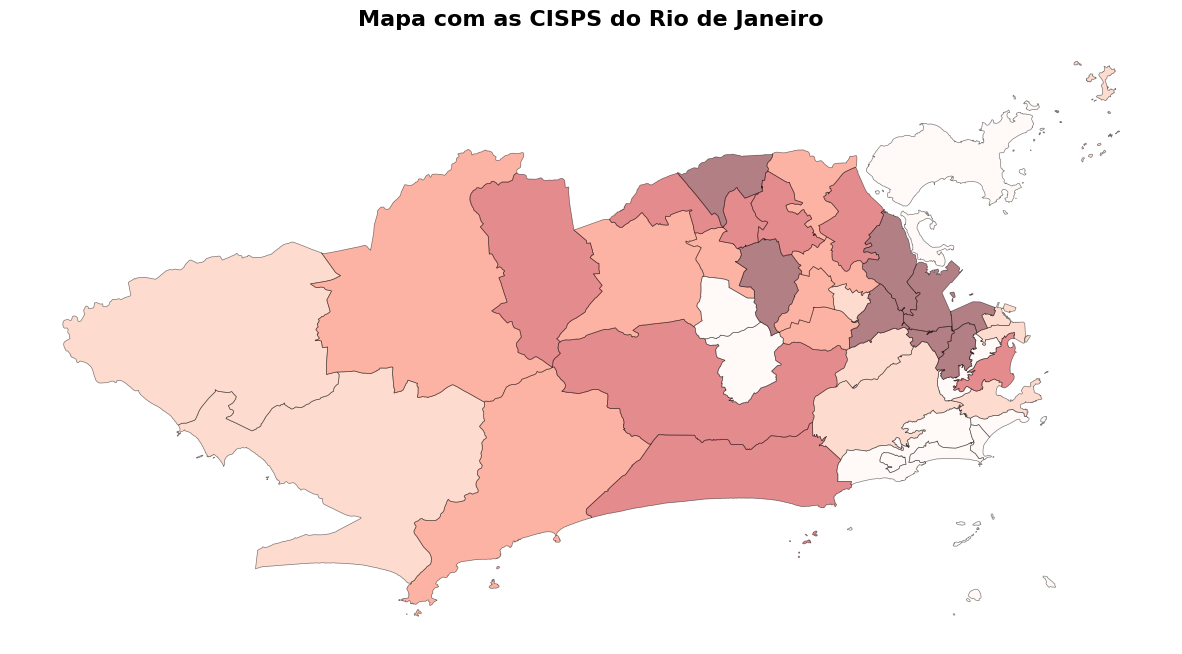

In [ ]:
#criando mapa do rio com infos das localizacoes e regioes para serem desenhadas
#e quantidade de roubos em cada regiao pra fazer mapa de calor (cruzamos com crimes_por_cisp_ordenado)

import geopandas as gpd
import matplotlib.pyplot as plt
import mapclassify

mapa_cisp = gpd.read_file(path_shape)

mapa_cisp_final = mapa_cisp.merge(crimes_por_cisp_ordenado, on='cisp')
fig, ax = plt.subplots(figsize=(15, 8))

mapa_cisp_final.plot(ax=ax, edgecolor='black', linewidth=0.5, column='roubo_em_coletivo', cmap='Reds', scheme='quantiles', k=5, alpha=0.5)

ax.set_title('Mapa com as CISPS do Rio de Janeiro', fontsize=16, fontweight='bold')
ax.axis('off')

plt.show()

In [ ]:
import pandas as pd

colunas_shapes = ['shape_id', 'shape']
shapes = pd.read_csv(f"{path_data}/shapes_geom.csv", usecols=colunas_shapes)

#shapes.info()
#df_rotas.describe()
#df_rotas.isnull().sum()
#df_rotas.duplicated().sum()



shapes

,shape_id,shape
0,1oge,"LINESTRING(-43.232036 -22.923777, -43.23146 -2..."
1,9ptt,"MULTILINESTRING((-43.29031 -22.90076, -43.2902..."
2,35bu,"MULTILINESTRING((-43.17754 -22.90107, -43.1775..."
3,iz18,"LINESTRING(-43.19987 -22.93997, -43.19975 -22...."
4,2ibq,"LINESTRING(-43.621884 -22.968783, -43.62189 -2..."
...,...,...
13941,39yj,"MULTILINESTRING((-43.37424 -22.92339, -43.3742..."
13942,lfjt,"LINESTRING(-43.28495 -22.87456, -43.28583 -22...."
13943,bfne,"MULTILINESTRING((-43.33508 -22.96399, -43.3350..."
13944,ejro,"MULTILINESTRING((-43.18086 -22.90192, -43.1791..."


In [ ]:
import pandas as pd
import geopandas as gpd
from shapely import wkt

colunas_shapes = ['shape_id', 'shape']
shapes = pd.read_csv(f"{path_data}/shapes_geom.csv", usecols=colunas_shapes)

shapes_filtrados = shapes[shapes['shape_id'].isin(infos_dos_bus['shape_id'])].dropna(subset=['shape']).copy()

#converte o texto de linestring() em linha matematica p gpd entender que da pra desenhar linha de rota
bus_com_trajeto = shapes_filtrados.merge(infos_dos_bus, on='shape_id')

print(bus_com_trajeto.isnull().sum())

'''
bus_com_trajeto['geometry'] = bus_com_trajeto['shape'].apply(wkt.loads)

linhas_onibus_geo = gpd.GeoDataFrame(bus_com_trajeto, geometry='geometry', crs="EPSG:4326")

linhas_onibus_geo['geometry'] = linhas_onibus_geo['geometry'].simplify(tolerance=0.0005)


linhas_onibus_geo.plot()
linhas_onibus_geo.info()
'''

shape_id     0
shape        0
route_id     0
numero       0
descricao    0
trip_id      0
nome         0
ida          0
volta        0
dtype: int64


'\nbus_com_trajeto[\'geometry\'] = bus_com_trajeto[\'shape\'].apply(wkt.loads)\n\nlinhas_onibus_geo = gpd.GeoDataFrame(bus_com_trajeto, geometry=\'geometry\', crs="EPSG:4326")\n\nlinhas_onibus_geo[\'geometry\'] = linhas_onibus_geo[\'geometry\'].simplify(tolerance=0.0005)\n\n\nlinhas_onibus_geo.plot()\nlinhas_onibus_geo.info()\n'

In [ ]:
#criando linhas por onde os onibus passam

import pandas as pd
import geopandas as gpd
from shapely import wkt
import os

path_data = os.path.join("..", "data")

colunas_pra_ler = ['shape_id', 'shape']
shapes = pd.read_csv(f"{path_data}/shapes_geom.csv", usecols=colunas_pra_ler)

display(infos_dos_bus)
bus_com_trajeto = shapes.merge(infos_dos_bus, on='shape_id')
display(bus_com_trajeto)
#converte o texto de linestring() em linha matematica p gpd entender que da pra desenhar linha de rota
bus_com_trajeto['geometry'] = bus_com_trajeto['shape'].apply(wkt.loads)

colunas_inuteis = ['feed_version', 'feed_start_date', 'feed_end_date', 'shape_distance', 'start_pt', 'end_pt', 'versao_modelo', 'shape']
bus_com_trajeto.drop(columns=colunas_inuteis, inplace=True, errors='ignore')

linhas_onibus_geo = gpd.GeoDataFrame(bus_com_trajeto, geometry='geometry', crs="EPSG:4326")



#bus_com_trajeto.head()
linhas_onibus_geo.plot()
linhas_onibus_geo.info()

NameError: name 'path_data' is not defined

In [ ]:
#mapa com as linhas

import matplotlib.pyplot as plt

fig,ax = plt.subplots(figsize=(15,8))
mapa_cisp_final.plot(ax=ax, edgecolor='black', linewidth=0.5, column='roubo_em_coletivo', cmap='Reds', scheme='quantiles', k=5, alpha=0.5)
linhas_onibus_geo.plot(ax=ax, color='blue', linewidth=0.4, alpha=0.4)
ax.set_title('Mapa com linhas de ônibus e áreas de risco de roubos', fontsize=16, fontweight='bold')
ax.axis('off')
plt.show()

In [ ]:
#plotar apenas linha de um onibus especifico (usei pq 325 tava dando 10 de risco em uma analise e queria ter uma visao melhor da rota dele pra entender o problema)

import matplotlib.pyplot as plt

linha_325 = linhas_onibus_geo[linhas_onibus_geo['numero'] == '325']
ida = linha_325[linha_325['ida'] == 1]
volta = linha_325[linha_325['volta'] == 1]

fig, ax = plt.subplots(figsize=(15, 8))
mapa_cisp_final.plot(ax=ax, edgecolor='black', linewidth=0.5, column='roubo_em_coletivo', cmap='Reds', scheme='quantiles', k=5, alpha=0.5)
ida.plot(ax=ax, color='blue', linewidth=2, label='Ida')
volta.plot(ax=ax, color='green', linewidth=2, label='Volta')

ax.set_title('Trajeto 325 (Azul: Ida / Verde: Volta)')
ax.axis('off')
plt.show()


In [ ]:
#classificando nivel de risco de cada onibus

'''
classificacao feita pelo pd.qcut se mostrou nao ser a melhor forma -  agrupava de 10% em 10% (10% iniciais nota 1, 10% seguintes n2)
risco_por_linha['nota_risco'] = pd.qcut(risco_por_linha['exposicao_roubo_total'], 10, labels=False) + 1
'''

import pandas as pd
import numpy as np
import geopandas as gpd

onibus_com_crimes_completo = gpd.sjoin(linhas_onibus_geo, mapa_cisp_final, predicate='intersects')

onibus_com_crimes = onibus_com_crimes_completo.drop_duplicates(subset=['route_id', 'ida', 'volta', 'cisp'])

risco_por_linha = onibus_com_crimes.groupby(['route_id', 'ida', 'volta', 'numero'],as_index=False)['roubo_em_coletivo'].sum()

risco_por_linha.rename(columns={'roubo_em_coletivo': 'exposicao_roubo_total'}, inplace=True)

risco_por_linha['nota_risco'], limites = pd.cut(risco_por_linha['exposicao_roubo_total'],bins=5,labels=[1, 2, 3, 4, 5],retbins=True)

limites
display(risco_por_linha['nota_risco'].value_counts().sort_index())

resultado = risco_por_linha[risco_por_linha['numero'].isin(['696', '325', '324'])]
display(resultado)

'''
calcular exposicao a risco de ponto a ao b
tentar ver de somar exposicao ao risco em integração (??) - como tenho todos os pontos do 325, talvez colocar uma caixa seletora onde o usuario consiga selecionar o ponto de entrada, de saida do onibus (pode selecionar clicando no mapa tb, tentar ver integraçap)
Ou comparar

Mudar cores -

Esquece usuario comum - focar na Política pública(!!!!!!!)

5 - perigoso - fica em casa irmao
4 - alto risco - guarda o celular
3 - medio risco - um olho aberto outro fechado
2 - baixo risco - pode usar o celular
1 - seguro - cochila a vontade

No relatório - Chatbox com gemini
'''

In [ ]:
#p analisar qual metodo melhor - pd.qcut se mostrou ruim pq mt concentraçao em um ponto

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(12, 6))

sns.histplot(risco_por_linha['exposicao_roubo_total'], bins=40, kde=True, color='darkred', ax=ax)

ax.set_title('Roubos x Trajeto de Ônibus', fontsize=16, fontweight='bold')
ax.set_xlabel('Total de Roubos no trajeto', fontsize=12)
ax.set_ylabel('Quantidade de Linhas de Ônibus', fontsize=12)
ax.spines['top'].set_visible(False)#tirar linhas
ax.spines['right'].set_visible(False)

plt.show()



In [ ]:
# Limpeza de stop_times - lista sequencia de paradas

import geopandas as gpd
import matplotlib.pyplot as plt

colunas_uteis = ['trip_id', 'stop_id', 'stop_sequence']
seq_paradas_sujo = pd.read_csv(f"{path_data}/stop_times.txt", usecols=colunas_uteis)

viagens_de_interesse = infos_dos_bus['trip_id']
seq_paradas_filtrado = seq_paradas_sujo[seq_paradas_sujo['trip_id'].isin(viagens_de_interesse)].copy()

display(seq_paradas_filtrado)


#seq_paradas_filtrado.info()
#seq_paradas_filtrado.isnull().sum() # 0 nulos
#seq_paradas_filtrado.duplicated().sum() # 0 duplicadas
seq_paradas_filtrado.describe()





In [ ]:
# Limpeza de stops.csv - cadastro dos pontos de paradas

import geopandas as gpd
import matplotlib.pyplot as plt


colunas_uteis_stops = ['stop_id', 'stop_name', 'stop_lat', 'stop_lon']
stops = pd.read_csv(f"{path_data}/stops.csv",usecols=colunas_uteis_stops)



stops[['stop_lat', 'stop_lon']].describe() # pra saber max e min e comparar com o rj (latitude: -22.9068 e longitude -43.1729) // deu bom


#stops.info() # mts valores nulos pra tratar // # legal: me diz qnd de ram consome -tava consumindo mais de 70MB da RAM, agora, 14.8+
#stops.isnull().sum() # (vi com .infos e .isnull) - optei por apagar por ser cerca de 10% - pensei em estimar long e latitude (ideia do bernardo era ver onibus com pontos de onibus q passam perto) - chegamos no raciocinio que eh melhor pro usuario nao ter do que ter errado
#stops.dropna(subset=['stop_lat', 'stop_lon'], inplace=True)

#stops.duplicated().sum()
#stops.drop_duplicates(subset=['stop_id'], keep='first', inplace=True)


NameError: name 'pd' is not defined

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

pontos_com_seq = seq_paradas_filtrado.merge(
    stops[['stop_id', 'stop_name', 'stop_lat', 'stop_lon']],
    on='stop_id',
    how='inner'
)

pontos_com_seq = pontos_com_seq.sort_values(by=['trip_id', 'stop_sequence']) # garantir que ponto 2 venha dps do 1
pontos_com_seq.columns


#from google.colab import files #vamos baixar esse arquivo pra jogar no streamlit ele ja tratado

#files.download('pontos_com_seq_tratado.parquet')

In [ ]:
#COM STOPS QUERO:
#melhorar risco (qm tem mais paradas tem mais risco)
#conseguir filtrar e recalcular risco com base num ponto de partida e fim (clicando no ponto no mapa ou filtrando mesmo)


# COMPARAR IDA E VOLTA
import geopandas as gpd
import matplotlib.pyplot as plt


route_id_325 = infos_dos_bus[infos_dos_bus['numero'] == '325']['route_id'].iloc[0]
trips_325 = df_trips[df_trips['route_id'] == route_id_325]['trip_id']
pontos_da_linha = pontos_com_seq[pontos_com_seq['trip_id'].isin(trips_325)]

if not pontos_da_linha.empty:
    trip_id_valido = pontos_da_linha['trip_id'].iloc[0]
    pontos_325 = pontos_da_linha[pontos_da_linha['trip_id'] == trip_id_valido].copy()

    pontos_325_geo = gpd.GeoDataFrame( #criando msm geometry q criei nas linhas pra avisar q o texto eh coordenada de gps
        pontos_325,
        geometry=gpd.points_from_xy(pontos_325['stop_lon'], pontos_325['stop_lat']),
        crs="EPSG:4326"
    )

    shape_id_valido = df_trips[df_trips['trip_id'] == trip_id_valido]['shape_id'].iloc[0]
    tracado_325 = linhas_onibus_geo[linhas_onibus_geo['shape_id'] == shape_id_valido]
    fig, ax = plt.subplots(figsize=(12, 8))

    #mapa_cisp_final.plot(ax=ax, edgecolor='white', linewidth=0.5, color='lightgrey', alpha=0.5) #mais clean pra enxergar
    mapa_cisp_final.plot(ax=ax, column='roubo_em_coletivo', cmap='Reds', scheme='quantiles', k=5, edgecolor='black', linewidth=0.5, alpha=0.5)


    tracado_325.plot(ax=ax, color='blue', linewidth=3)

    pontos_325_geo.plot(ax=ax, color='lime', markersize=15, edgecolor='black', zorder=5)

    minx, miny, maxx, maxy = tracado_325.total_bounds
    margem = 0.02
    ax.set_xlim(minx - margem, maxx + margem)
    ax.set_ylim(miny - margem, maxy + margem)

    ax.set_title('Trajeto e Paradas - grande e bom 325', fontsize=16, fontweight='bold')
    ax.axis('off')
    plt.show()

else:
    print("Linha não encontrada. Verifique se o número tem espaço ou letra (ex: '325 ' ou 'SP325').")